In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Any, Optional, Tuple
import os
from pathlib import Path
import re
import json

# Set publication-ready style
plt.style.use('default')
plt.rcParams.update({
    'font.size': 28,
    # Slightly smaller axis label + tick label sizes
    'axes.labelsize': 32,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.8,
    'legend.frameon': True,
    'legend.fancybox': False,
    'legend.shadow': False,
    'legend.framealpha': 0.9,
    'legend.edgecolor': 'black',
    'legend.borderpad': 0.5,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'lines.linewidth': 2,
    'lines.markersize': 6,
})

# Set elegant color palette
colors_elegant = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#7209B7', '#2F9B5B']
sns.set_palette(colors_elegant)

# Consistent colors by method (loss_type)
_METHOD_COLORS = {
    'avg': colors_elegant[0],
    'aug_dual': colors_elegant[1],
    'penalty': colors_elegant[5],
    'resilient': colors_elegant[3],
}

def method_color(loss_type: str) -> str:
    return _METHOD_COLORS.get(loss_type, '#333333')

def _normalize_to_unit(x: float, vmin: Optional[float], vmax: Optional[float]) -> float:
    if vmin is None or vmax is None or vmax == vmin:
        return 0.5
    return (x - vmin) / (vmax - vmin)

def _alpha_lw_from_unit(
    t: float,
    *,
    alpha_min: float = 0.4,
    alpha_max: float = 0.8,
    lw_min: float = 3.5,
    lw_max: float = 3.5,
) -> Tuple[float, float]:
    """Map normalized t in [0,1] to (alpha, linewidth) with a subtle but visible spread."""
    t = float(np.clip(t, 0.0, 1.0))
    alpha = alpha_min + (alpha_max - alpha_min) * t
    lw = lw_min + (lw_max - lw_min) * t
    return alpha, lw


# Legend display names
_METHOD_ABBREV = {
    'penalty': 'pen',
    'aug_dual': 'point',
    'resilient': 'relax',
    'avg': 'avg',
}

def method_abbrev(loss_type: str) -> str:
    return _METHOD_ABBREV.get(loss_type, str(loss_type))


def _fmt_hp(v) -> str:
    """Format hyperparameters using the original (non-log) values with clean display."""
    if v is None:
        return "?"
    try:
        # Preserve ints like 1,10,100 (even if stored as 1.0)
        fv = float(v)
        if abs(fv - round(fv)) < 1e-9:
            return str(int(round(fv)))
        return f"{fv:g}"
    except Exception:
        return str(v)


def format_method_label(entry: dict) -> str:
    lt = entry.get('loss_type')
    label = method_abbrev(lt)
    if lt == 'penalty' and entry.get('alpha') is not None:
        label += f" ($\lambda_0=${_fmt_hp(entry['alpha'])})"
    if lt == 'avg' and entry.get('loss_tol') is not None:
        label += f" (ε={_fmt_hp(entry['loss_tol'])})"
    if lt == 'resilient' and entry.get('resilient_coef') is not None:
        label += f" (β={_fmt_hp(entry['resilient_coef'])})"
    return label


def _maybe_log10(x: float, hp_key: str) -> float:
    # ε, β, and penalty $\lambda_0$ are often log-spaced (e.g., 1, 10, 100). Normalize in log-space.
    if hp_key in {'loss_tol', 'resilient_coef', 'alpha'} and x > 0:
        return float(np.log10(x))
    return x


def style_for_entry(
    entry: dict,
    hp_key: str,
    *,
    hp_min: Optional[float] = None,
    hp_max: Optional[float] = None,
    **_ignored,
) -> dict:
    # Hyperparameter -> transparency + line thickness (normalized to be readable)
    val = entry.get(hp_key)
    if val is None:
        alpha, lw = 0.90, 4.5
    else:
        v = _maybe_log10(float(val), hp_key)
        vmin = _maybe_log10(float(hp_min), hp_key) if hp_min is not None else None
        vmax = _maybe_log10(float(hp_max), hp_key) if hp_max is not None else None
        t = _normalize_to_unit(v, vmin, vmax)
        alpha, lw = _alpha_lw_from_unit(t)
    return {
        'color': method_color(entry.get('loss_type')),
        'alpha': alpha,
        'linewidth': lw,
    }

# Configuration
# api_key = ""  # Fill in your wandb API key
wandb_project = "RERANKER-final-v2"
wandb_entity = "alelab"  # Leave None to use default entity

# Create output directory for PDFs
output_dir = Path("./paper_figures")
output_dir.mkdir(exist_ok=True)
print(f"Figures will be saved to: {output_dir.absolute()}")

Figures will be saved to: /Users/ihounie/constrained-sft-1/notebooks/paper_figures


In [2]:
api = wandb.Api()

# Get all runs from the project, then keep only runs with train.seed == 42
runs = list(api.runs(f"{wandb_entity}/{wandb_project}" if wandb_entity else wandb_project))
_before = len(runs)


def _run_train_seed(run, target: int = 42):
    """Match run.config.train.seed (int-compatible: 42, 42.0, etc.)."""
    v = run.config.get("train", {}).get("seed")
    try:
        return int(round(float(v)))
    except (TypeError, ValueError):
        return None


runs = [r for r in runs if _run_train_seed(r) == 42]
print(f"Total runs in project (before seed filter): {_before}")
print(f"Keeping train.seed==42: {len(runs)} runs")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/ihounie/.netrc.


Total runs in project (before seed filter): 299
Keeping train.seed==42: 287 runs


### COMPARISON OF CONSTRAINED AND PENALIZED METHODS

Filtered runs: 5
  Run: reranker-answerdotai/ModernBERT-base-aug_dual-lambda_loss-1-large, loss_type: aug_dual, loss_alpha: 1, loss_tol: 1
  Run: reranker-answerdotai/ModernBERT-base-avg-lambda_loss-1-large, loss_type: avg, loss_alpha: 1, loss_tol: 1
  Run: reranker-answerdotai/ModernBERT-base-aug_dual-lambda_loss-1.0-large, loss_type: aug_dual, loss_alpha: 0.1, loss_tol: 1
  Run: reranker-answerdotai/ModernBERT-base-aug_dual-lambda_loss-1.0-large, loss_type: aug_dual, loss_alpha: 10, loss_tol: 1
  Run: reranker-answerdotai/ModernBERT-base-penalty-lambda_loss-1-large, loss_type: penalty, loss_alpha: 1, loss_tol: 1
Saved figure to paper_figures/constraint_slack_cdf_(train).pdf


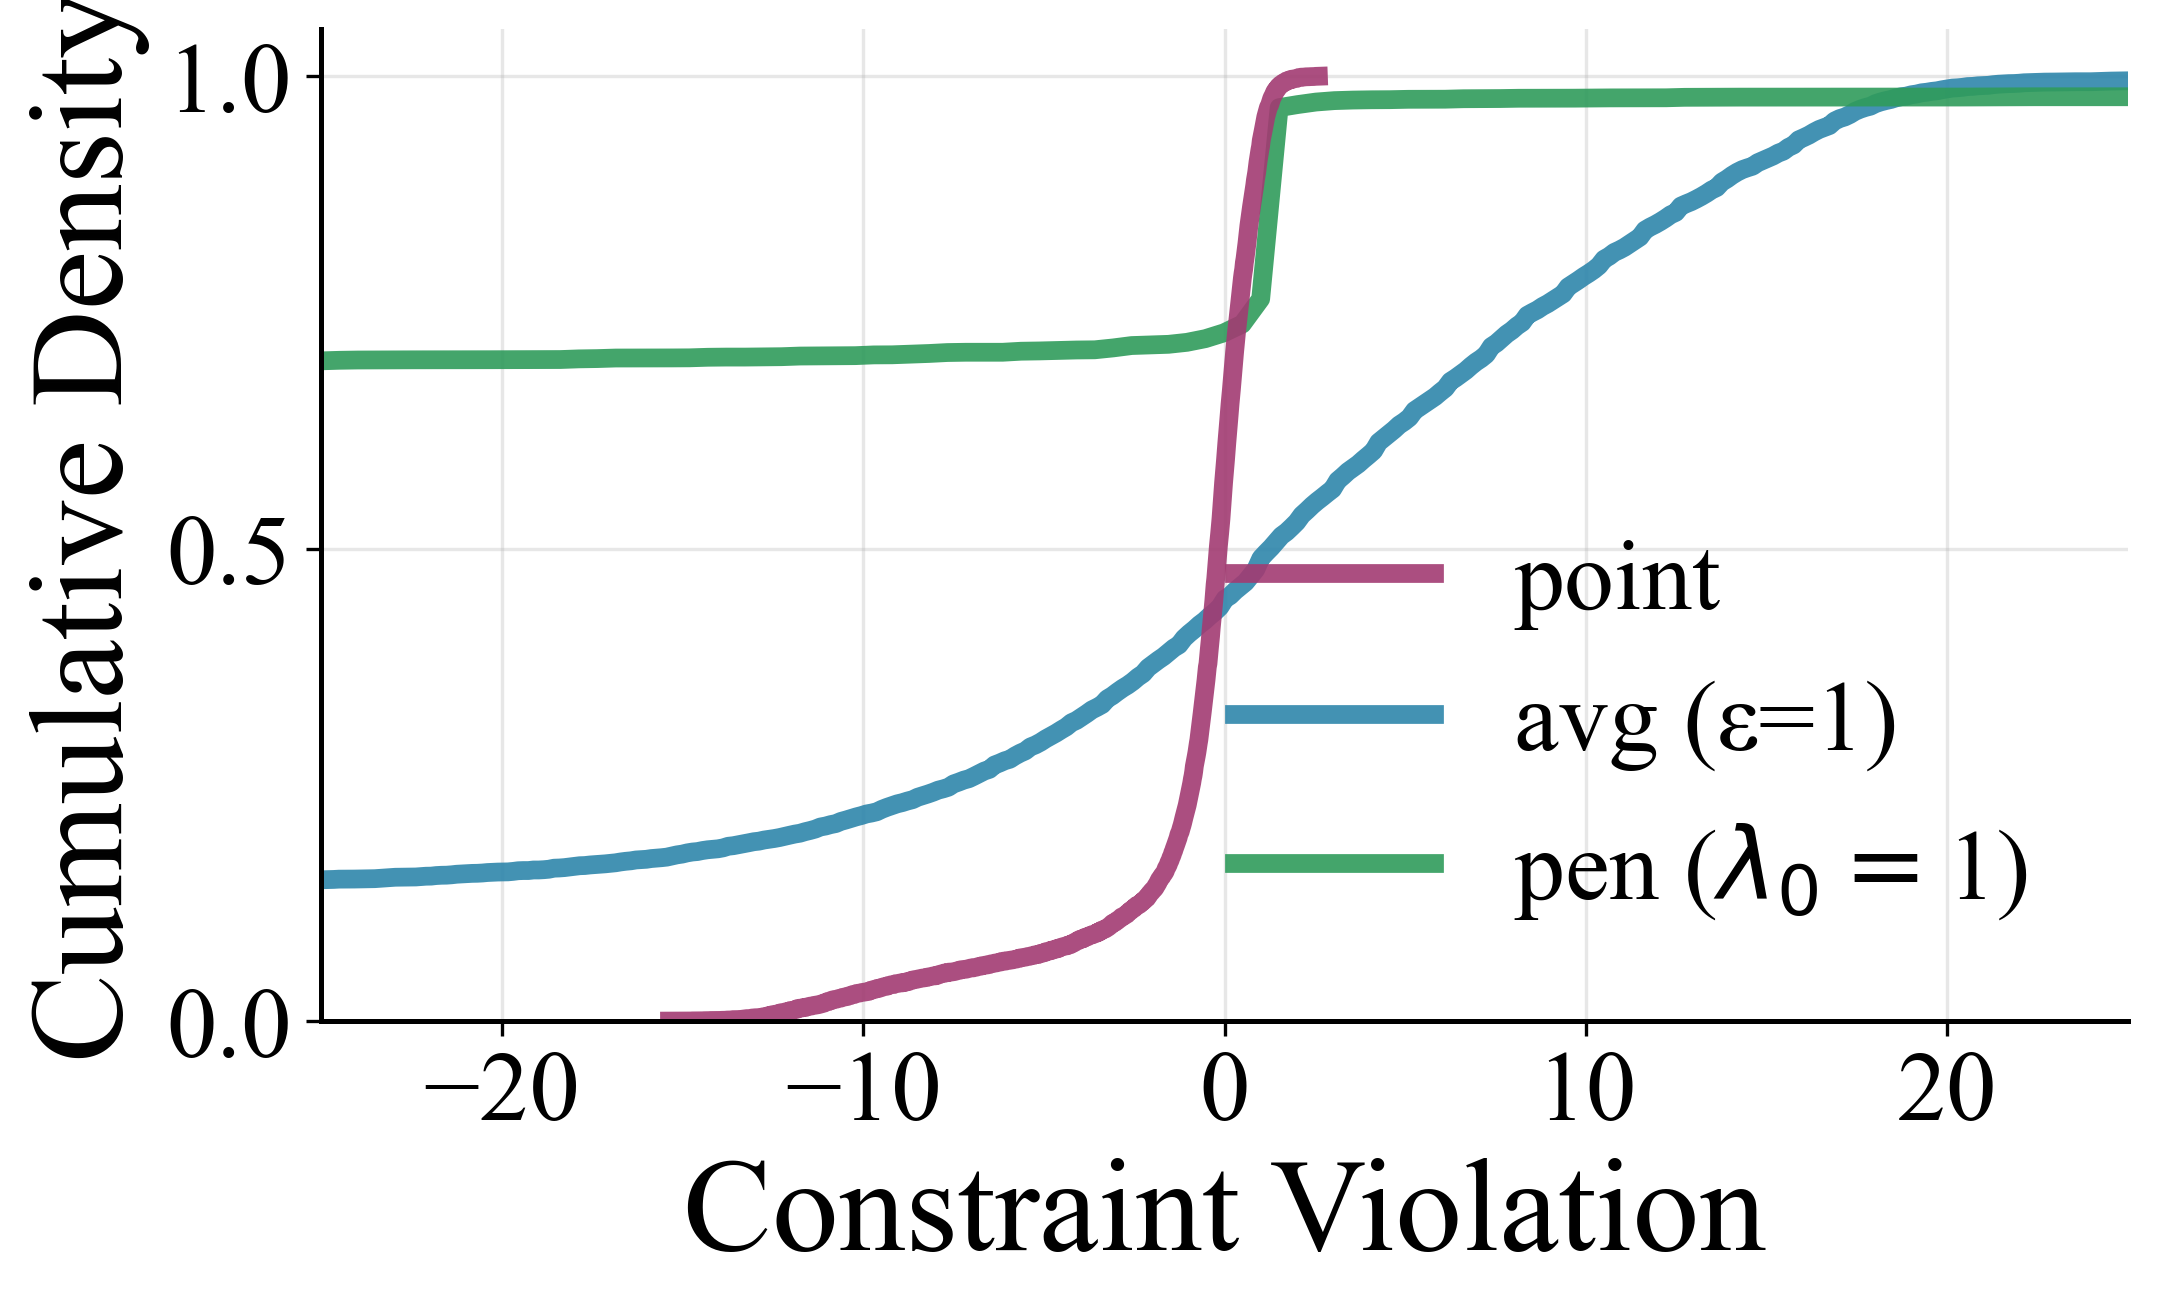

Saved figure to paper_figures/constraint_slack_cdf_(eval).pdf


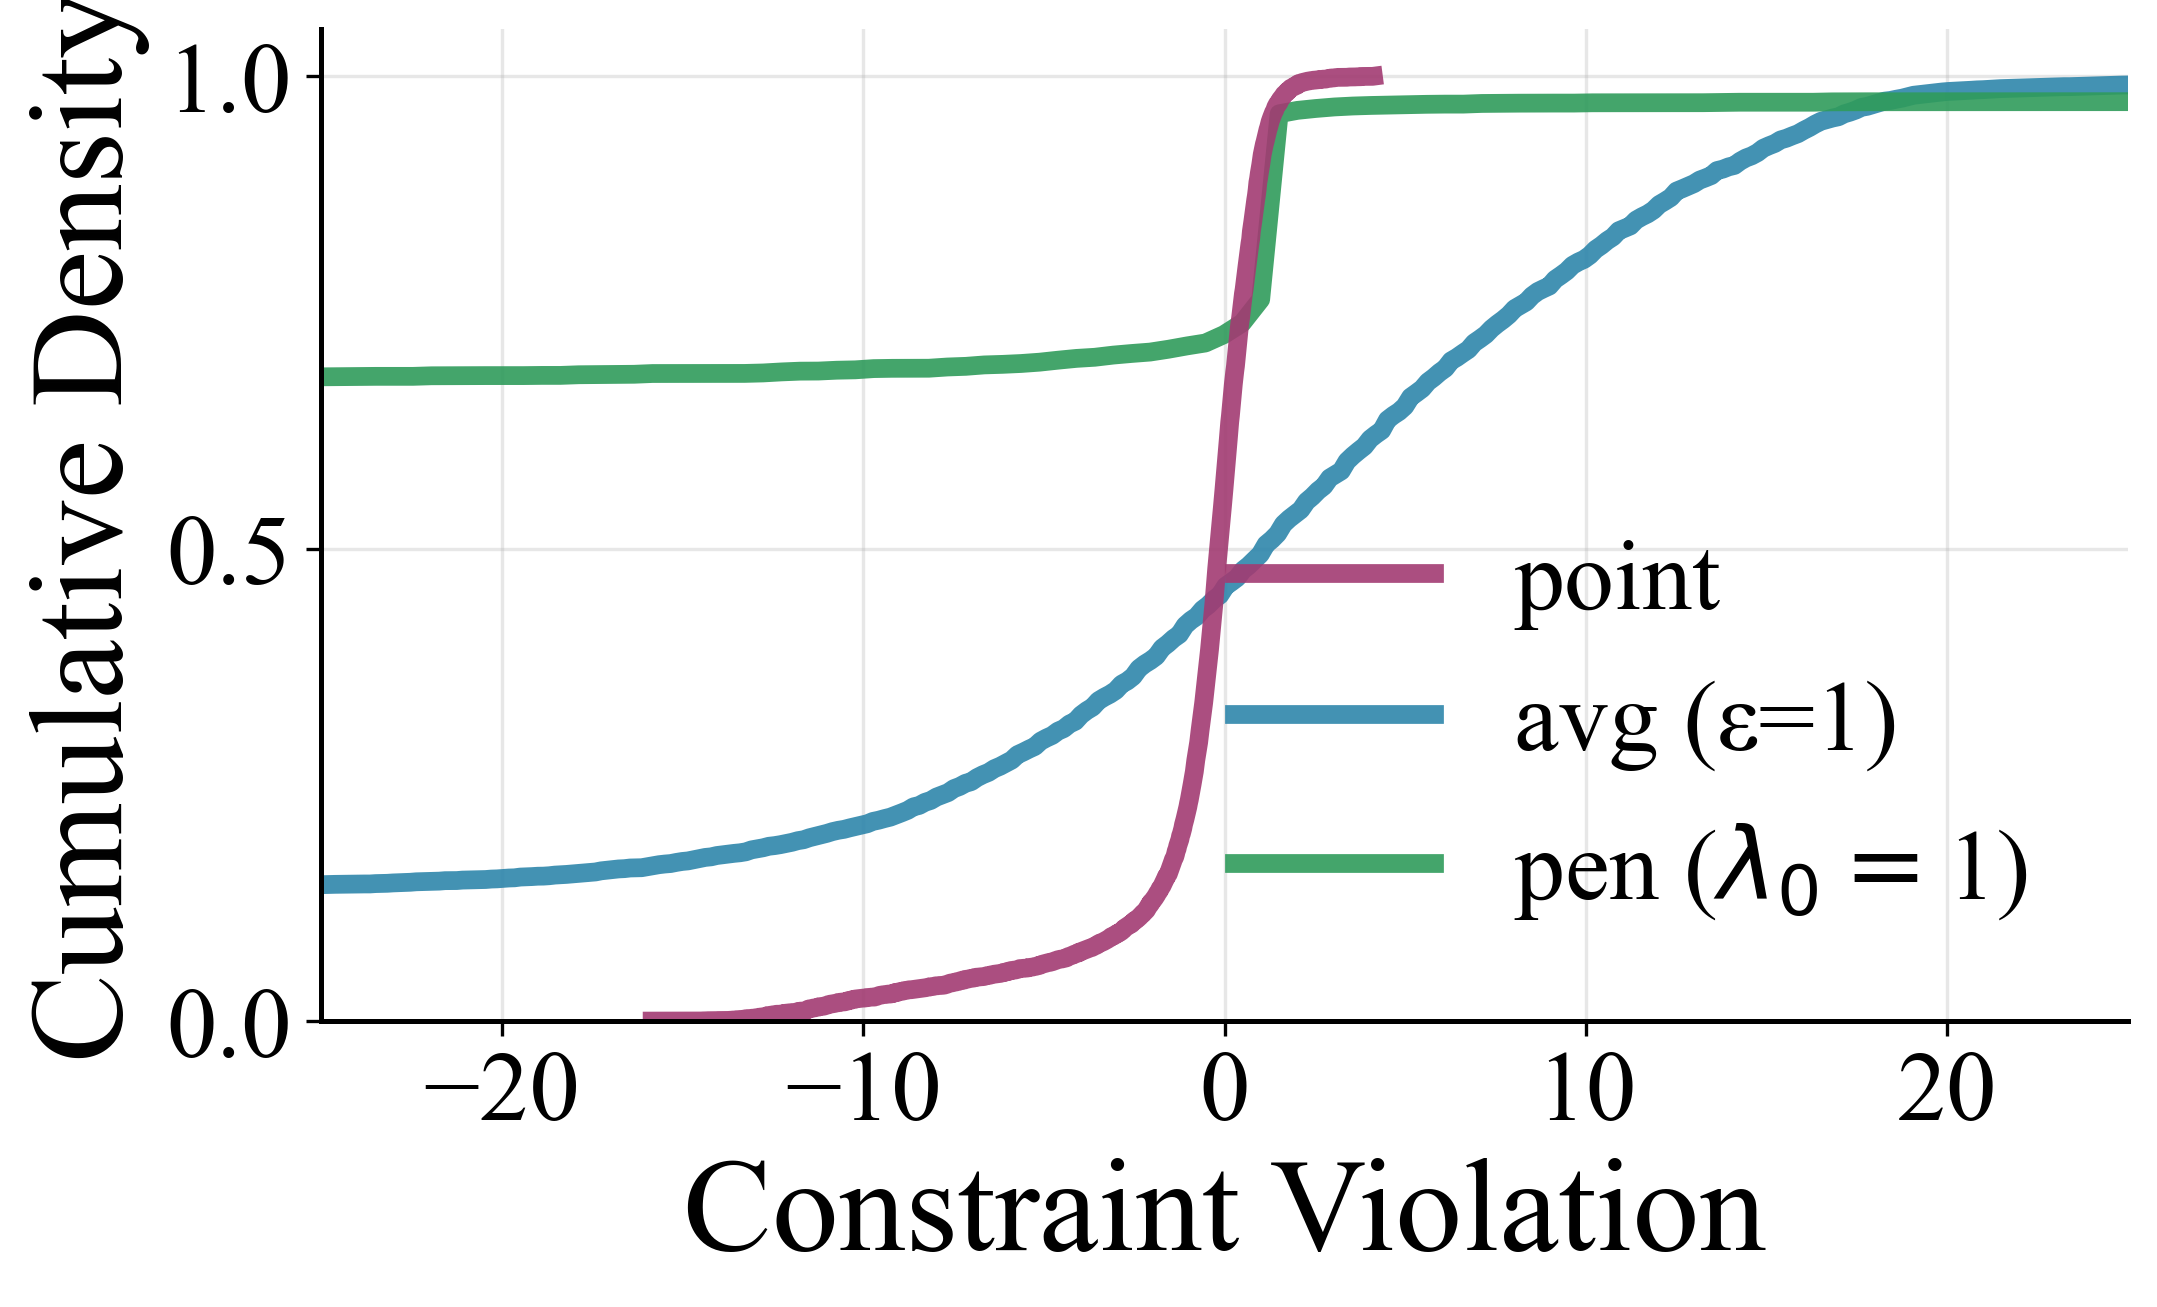

Train Slacks Statistics:
                 Method        Mean        Std       P90        P99   CVaR_90    CVaR_99        Max
               aug_dual   -0.917474   2.653248  0.894531   1.519531  1.181117   1.799159   2.597656
                    avg   -6.107908  24.487282 14.250000  20.875625 17.848707  28.280313  61.250000
penalty ($\lambda_0=$1) -167.928335 127.205072  1.000000 255.500000 20.986271 255.841121 256.000000

Eval Slacks Statistics:
                 Method        Mean        Std       P90        P99   CVaR_90    CVaR_99        Max
               aug_dual   -0.763170   2.476717  0.976562   1.962949  1.400539   2.527253   4.119141
                    avg   -5.888953  24.211993 13.625000  24.187500 19.008045  42.374821  78.750000
penalty ($\lambda_0=$1) -161.432510 131.195150  1.000000 255.500000 26.065409 255.899038 256.000000


In [3]:
# Filter runs and plot cumulative constraint slack histograms (train vs eval)


# PLOTTING AVG
loss_tol = [1.0]  # exp.loss_tol filter (set None to disable)
dropout = 0.05   # train.dropout filter (set None to disable)
model_name = "answerdotai/ModernBERT-base"
loss_type = ["avg","aug_dual","penalty"]
dual_step_size = [0.1]
loss_alpha = 1.0




def _run_passes_filters(run, loss_tol=None, dropout=None):
    cfg_exp = run.config.get('exp', {})
    cfg_train = run.config.get('train', {})
    if loss_tol is not None and cfg_exp.get('loss_tol') not in loss_tol:
        return False
    if dropout is not None and cfg_train.get('dropout') != dropout:
        return False
    if cfg_exp.get('model_name') != model_name:
        return False
    if cfg_exp.get('loss_type') not in loss_type:
        return False
    if cfg_exp.get('dual_step_size') not in dual_step_size and cfg_exp.get('loss_type') in ['aug_dual','avg']:
        return False
    if cfg_exp.get('loss_type') == 'penalty':
        if cfg_exp.get('loss_alpha') != loss_alpha:
            return False
    return True

filtered_runs = [r for r in runs if r.state == 'finished' and _run_passes_filters(r, loss_tol, dropout)]
print(f'Filtered runs: {len(filtered_runs)}')
# print loss_type and loss_alpha for each filtered run
for r in filtered_runs:
    loss_type = r.config.get('exp', {}).get('loss_type')
    loss_alpha = r.config.get('exp', {}).get('loss_alpha')
    print(f'  Run: {r.name}, loss_type: {loss_type}, loss_alpha: {loss_alpha}, loss_tol: {r.config.get("exp", {}).get("loss_tol")}')


# filtered_runs = [r for i, r in enumerate(filtered_runs) if i in indexes_to_filter]

pattern = re.compile(
    r'^(?:.*/)?constraint_slacks_epoch_([0-9.]+)_(train|eval)_(\d+)_([A-Za-z0-9]+)\.table\.json$'
)

def _latest_constraint_file(run, split):
    # Pick the file with the max epoch; tie-breaker max step
    candidates = []
    for f in list(run.files(per_page=1000)):
        m = pattern.match(f.name)
        if not m:
            continue
        epoch = float(m.group(1))
        file_split = m.group(2)
        step = int(m.group(3))
        if file_split != split:
            continue
        candidates.append((epoch, step, f))
    if not candidates:
        return None
    candidates.sort(key=lambda x: (x[0], x[1]))
    return candidates[-1][2]

def _load_constraint_slacks(file_obj, run_id, loss_tol):
    run_dir = Path('./wandb_downloads') / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    local_path = run_dir / file_obj.name
    file_obj.download(root=str(run_dir), replace=True)
    with open(local_path, 'r') as f:
        data = json.load(f)
    slacks = []
    for row in data.get('data', []):
        if row:
            slacks.append(float(row[0])-loss_tol + 1.0)
    return slacks

def _collect_slacks_by_split(runs, split):
    out = []
    aug_dual_kept = False
    for run in runs:
        f = _latest_constraint_file(run, split)
        if f is None:
            continue
        try:
            slacks = _load_constraint_slacks(f, run.id, loss_tol=run.config.get('exp', {}).get('loss_tol'))
        except Exception as e:
            print(f'Failed to load {split} slacks for {run.name}: {e}')
            continue

        # Keep only ONE aug_dual baseline run (ε=1, and default loss_alpha=1 if present)
        if run.config.get('exp', {}).get('loss_type') == 'aug_dual':
            try:
                if float(run.config.get('exp', {}).get('loss_tol')) != 1.0:
                    continue
                loss_alpha = run.config.get('exp', {}).get('loss_alpha')
                if loss_alpha is not None and float(loss_alpha) != 1.0:
                    continue
            except Exception:
                continue

            if aug_dual_kept:
                continue
            aug_dual_kept = True

        out.append({
            'run_id': run.id,
            'run_name': run.name,
            'loss_type': run.config.get('exp', {}).get('loss_type'),
            'slacks': np.array(slacks, dtype=float),
            'alpha': run.config.get('exp', {}).get('loss_alpha'),
            'loss_tol': run.config.get('exp', {}).get('loss_tol'),
        })
    return out

def _plot_cumulative(slack_sets, title):
    if not slack_sets:
        print(f'No data for {title}')
        return

    hp_key_by_loss_type = {
        'avg': 'loss_tol',  # ε
        'penalty': 'alpha',  # λ_o
        'resilient': 'resilient_coef',  # β
    }

    hp_ranges = {}
    for lt, hp_key in hp_key_by_loss_type.items():
        vals = [
            float(e.get(hp_key))
            for e in slack_sets
            if e.get('loss_type') == lt and e.get(hp_key) is not None
        ]
        uniq = sorted(set(vals))
        if len(uniq) > 1:
            hp_ranges[lt] = (hp_key, min(uniq), max(uniq))

    is_ablation = len(hp_ranges) > 0

    plt.figure(figsize=(8, 5))
    bins = 1000  # large number of bins for crude but smooth cumulative curve
    for entry in sorted(slack_sets, key=lambda e: e.get('loss_type') == 'aug_dual'):
        slacks = entry['slacks']
        counts, edges = np.histogram(slacks, bins=bins)
        cdf = np.cumsum(counts) / counts.sum() if counts.sum() > 0 else np.zeros_like(counts)
        x = edges[1:]

        lt = entry['loss_type']
        label = format_method_label(entry)
        if is_ablation and lt == 'aug_dual':
            label = '_nolegend_'

        style = {'color': method_color(lt), 'alpha': 0.90, 'linewidth': 4.5}
        if lt in hp_ranges:
            hp_key, hp_min, hp_max = hp_ranges[lt]
            style = style_for_entry(entry, hp_key, hp_min=hp_min, hp_max=hp_max)

        plt.plot(x, cdf, label=label, **style)

    plt.xlabel('Constraint Violation')
    plt.ylabel('Cumulative Density')
    plt.xlim(-25, 25)
    plt.ylim(0, 1.05)
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        point_idx = next((i for i, l in enumerate(labels) if str(l).startswith('point')), None)
        if point_idx is not None:
            handles = [handles[point_idx]] + [h for i, h in enumerate(handles) if i != point_idx]
            labels = [labels[point_idx]] + [l for i, l in enumerate(labels) if i != point_idx]
        ax.legend(handles, labels, frameon=False, fontsize=24, loc='lower right')
    plt.tight_layout()

    # save as pdf
    filename = title.lower().replace(' ', '_') + '.pdf'
    filepath = output_dir / filename
    plt.savefig(filepath)
    print(f'Saved figure to {filepath}')

    plt.show()

train_slacks = _collect_slacks_by_split(filtered_runs, 'train')
eval_slacks = _collect_slacks_by_split(filtered_runs, 'eval')

_plot_cumulative(train_slacks, 'Constraint Slack CDF (Train)')
_plot_cumulative(eval_slacks, 'Constraint Slack CDF (Eval)')



# Create a table with distribution statistics (mean, std, percentiles, CVaR) for train and eval slacks
def _compute_slack_statistics(slack_sets):
    """Compute statistics for slack distributions"""
    stats = []
    for entry in slack_sets:
        slacks = entry['slacks']
        stats.append({
            'Method': entry['loss_type'] if entry['loss_type'] != 'penalty' else f"penalty ($\lambda_0=${entry['alpha']})",
            'Mean': np.mean(slacks),
            'Std': np.std(slacks),
            'P90': np.percentile(slacks, 90),
            'P99': np.percentile(slacks, 99),
            'CVaR_90': np.mean(slacks[slacks >= np.percentile(slacks, 90)]),
            'CVaR_99': np.mean(slacks[slacks >= np.percentile(slacks, 99)]),
            'Max': np.max(slacks),
        })
    return pd.DataFrame(stats)

train_stats = _compute_slack_statistics(train_slacks)
eval_stats = _compute_slack_statistics(eval_slacks)

print("Train Slacks Statistics:")
print(train_stats.to_string(index=False))
print("\nEval Slacks Statistics:")
print(eval_stats.to_string(index=False))

Filtered runs: 6
  Run: reranker-answerdotai/ModernBERT-base-aug_dual-lambda_loss-1-large, loss_type: aug_dual, loss_alpha: 1, loss_tol: 1
  Run: reranker-answerdotai/ModernBERT-base-avg-lambda_loss-1-large, loss_type: avg, loss_alpha: 1, loss_tol: 1
  Run: reranker-answerdotai/ModernBERT-base-avg-lambda_loss-10-large, loss_type: avg, loss_alpha: 1, loss_tol: 10
  Run: reranker-answerdotai/ModernBERT-base-aug_dual-lambda_loss-1.0-large, loss_type: aug_dual, loss_alpha: 0.1, loss_tol: 1
  Run: reranker-answerdotai/ModernBERT-base-aug_dual-lambda_loss-1.0-large, loss_type: aug_dual, loss_alpha: 10, loss_tol: 1
  Run: reranker-answerdotai/ModernBERT-base-avg-lambda_loss-100-large, loss_type: avg, loss_alpha: 1, loss_tol: 100
Saved figure to paper_figures/constraint_slack_cdf_(train)_avg_.pdf


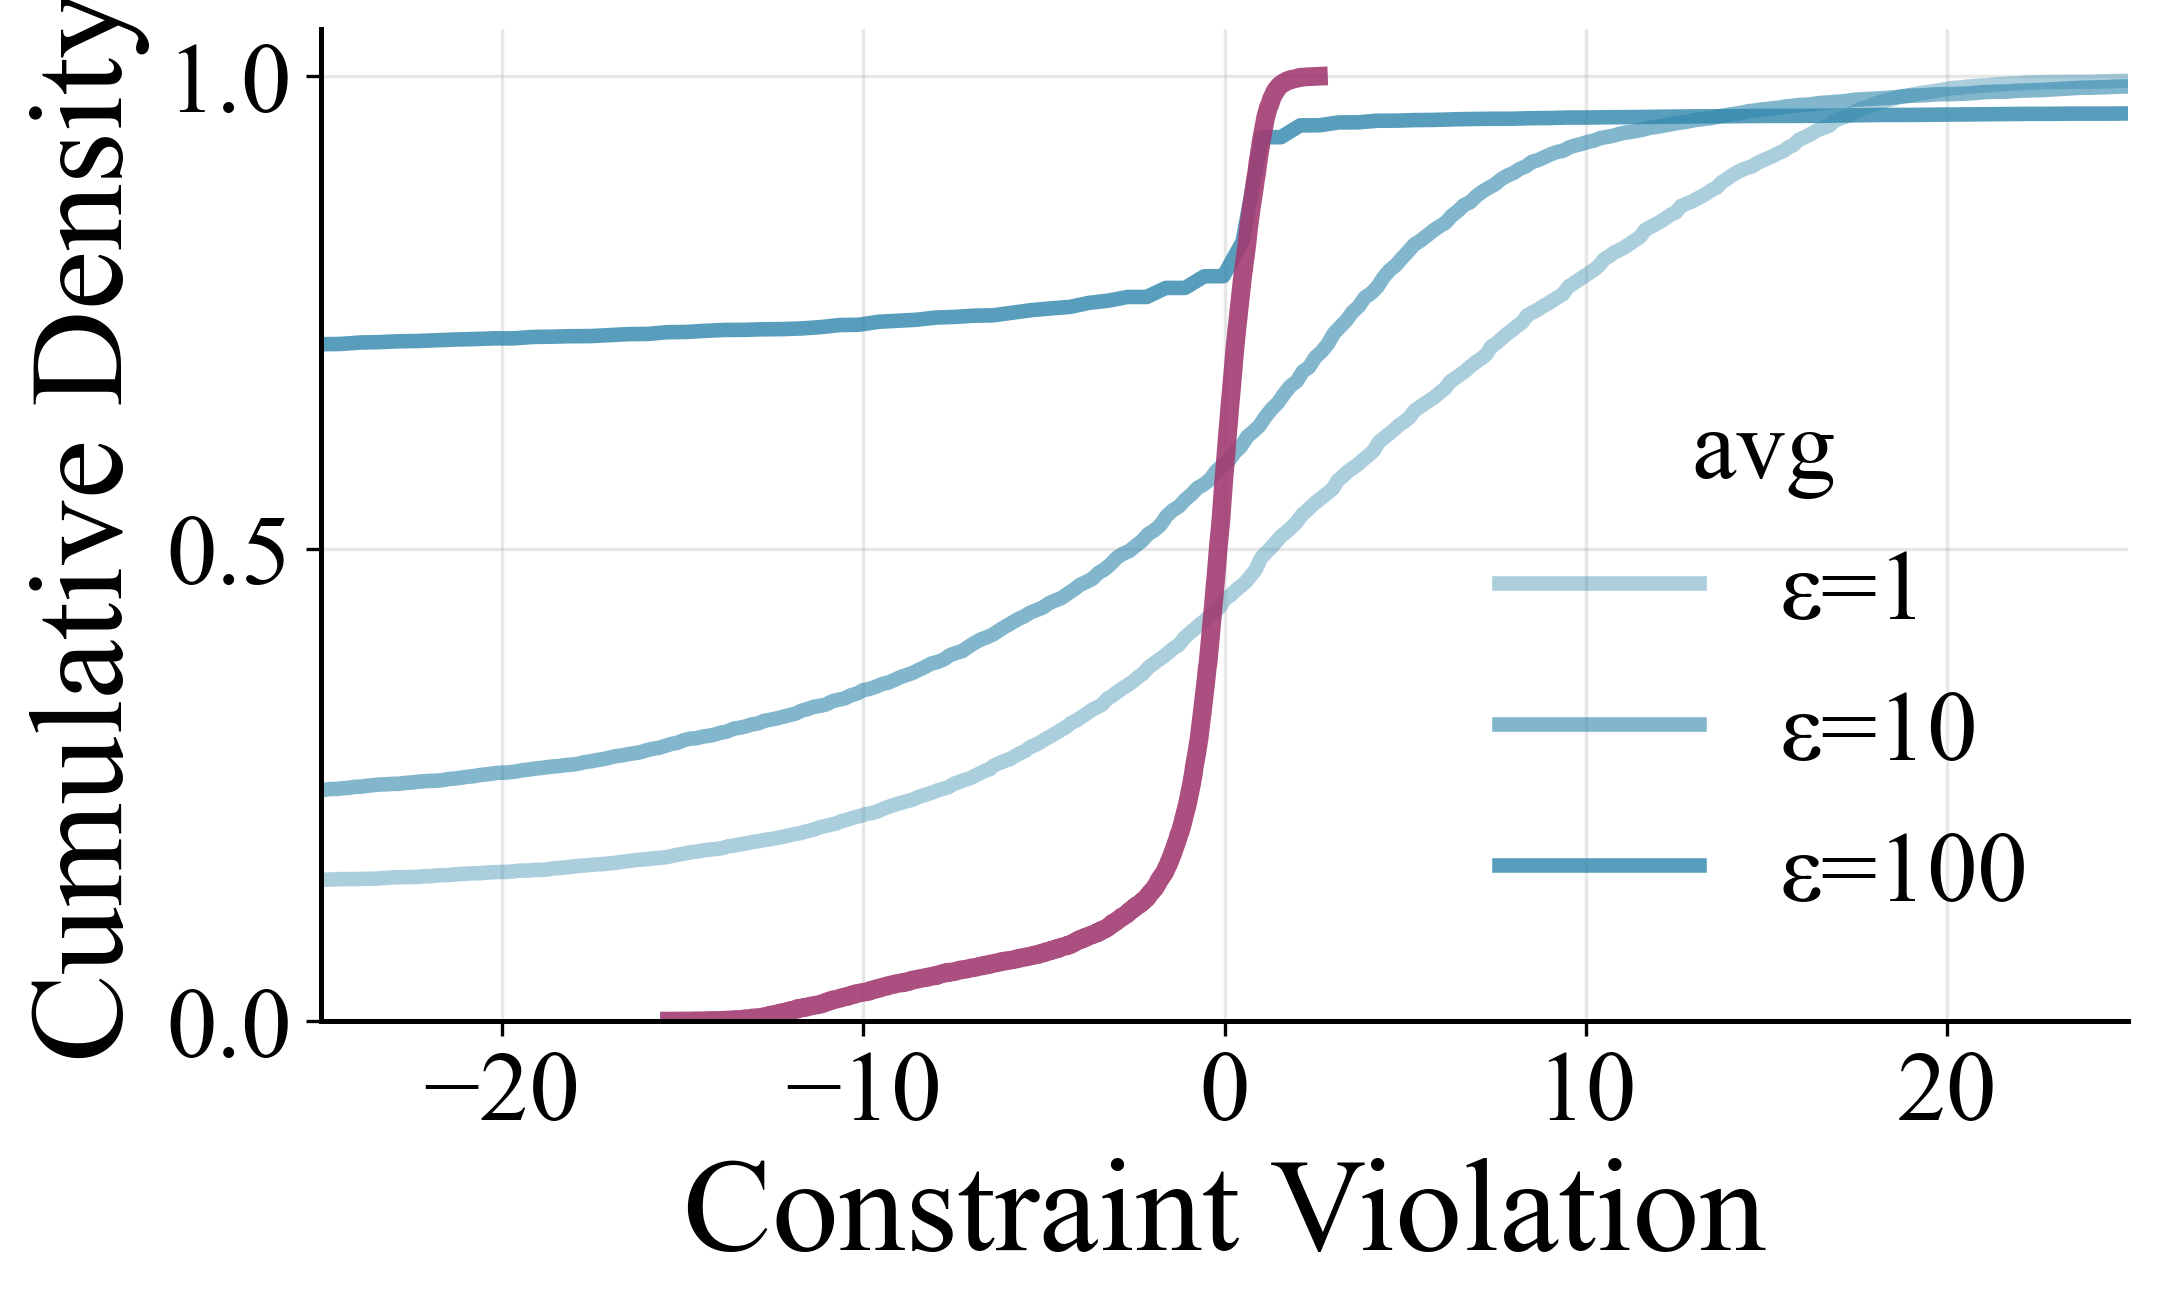

Saved figure to paper_figures/constraint_slack_cdf_(eval)_avg_.pdf


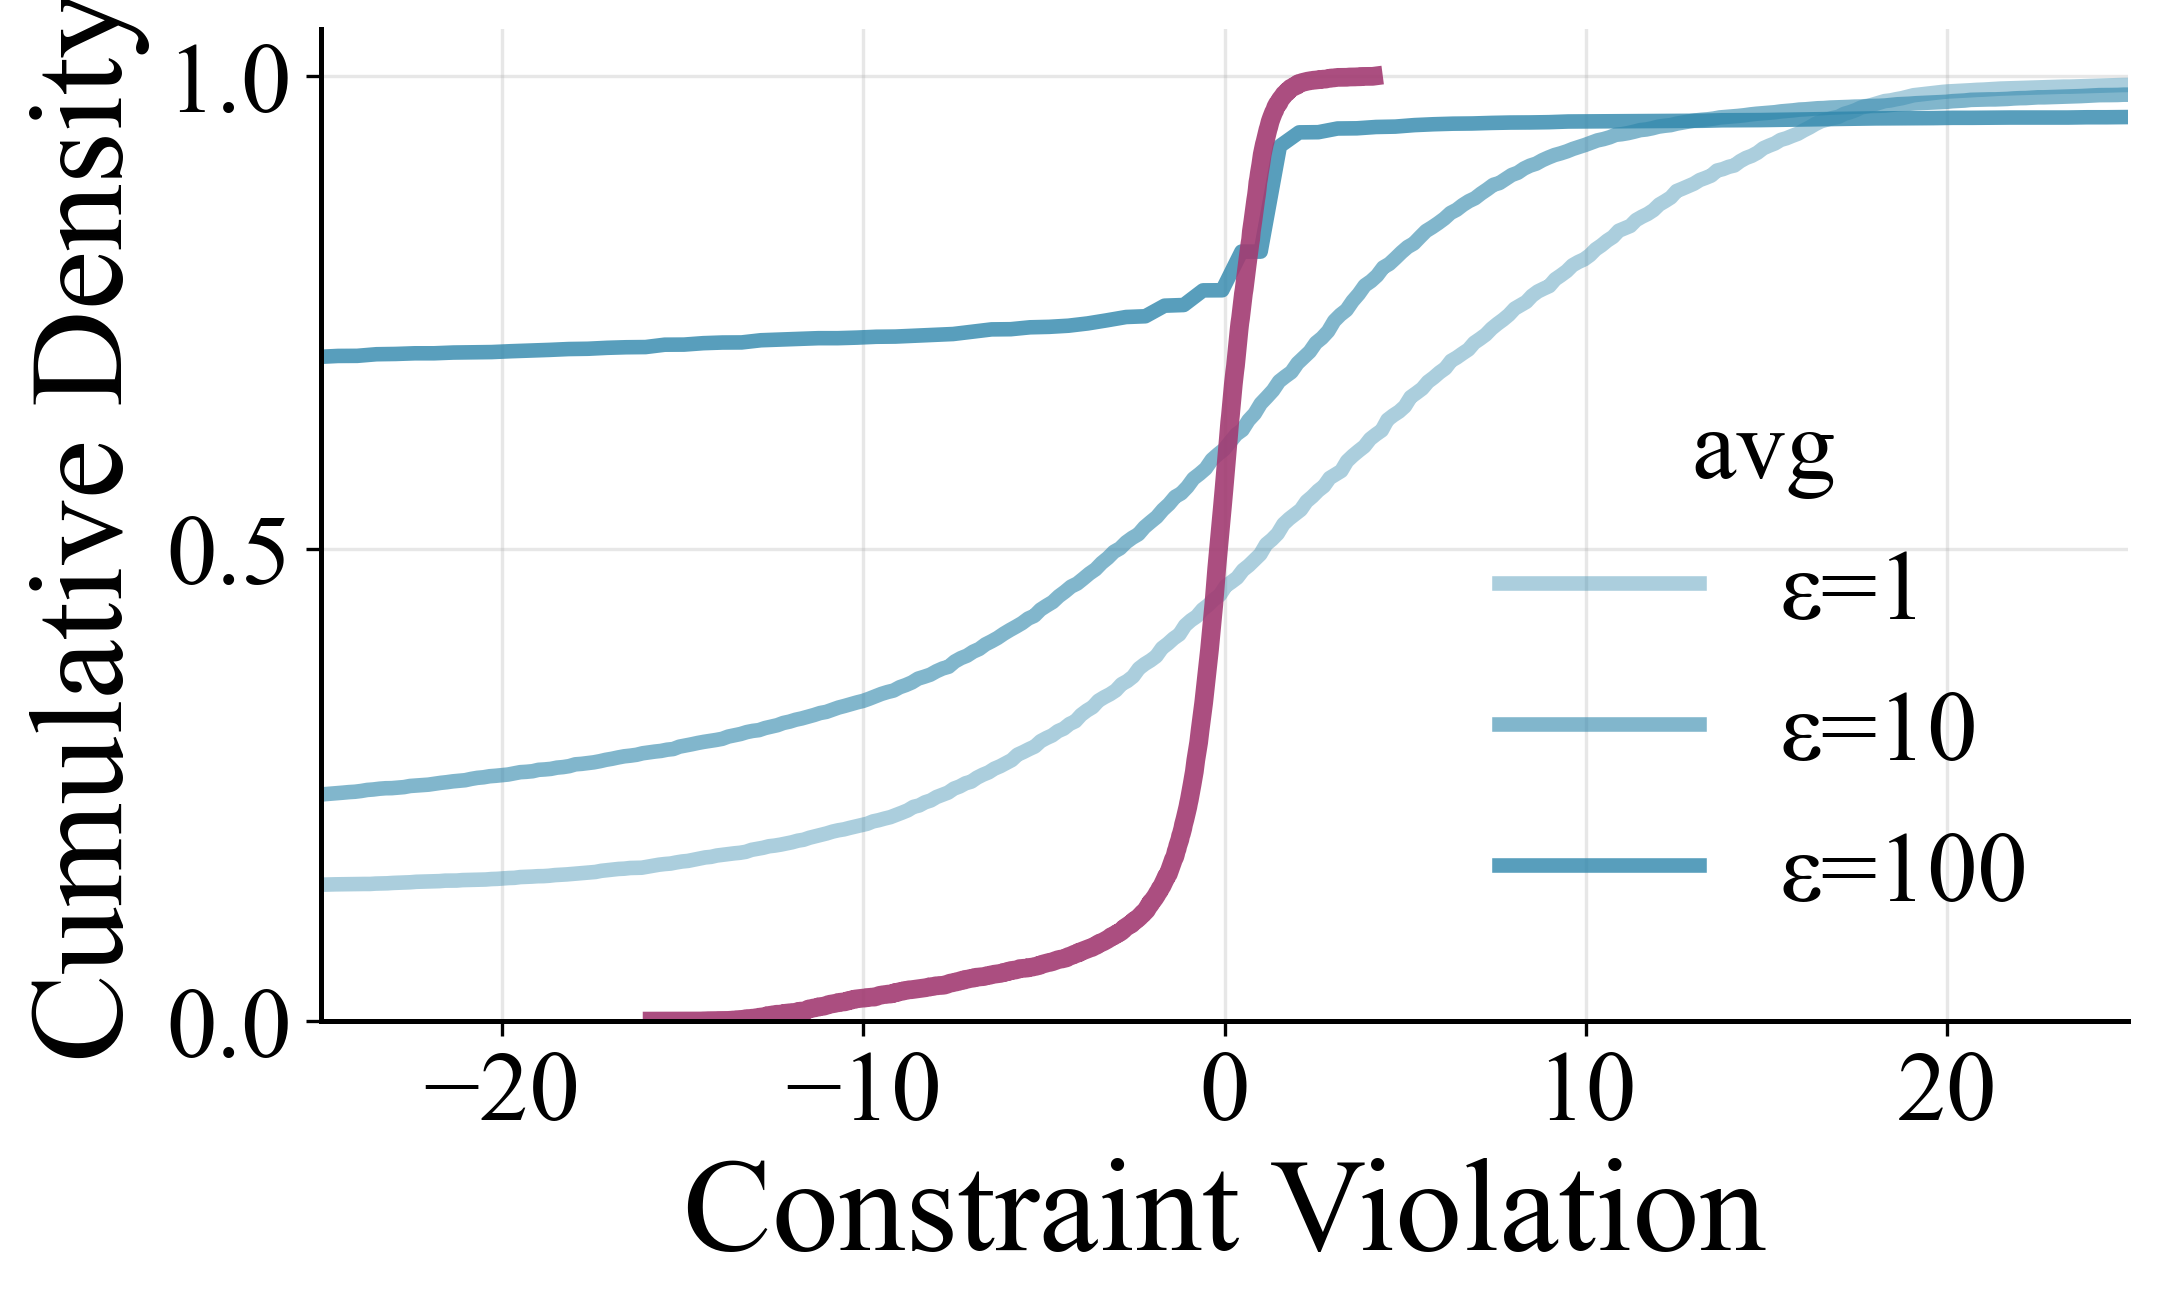

Train Slacks Statistics:
     Method        Mean        Std       P90        P99   CVaR_90    CVaR_99        Max
   aug_dual   -0.917474   2.653248  0.894531   1.519531  1.181117   1.799159   2.597656
  avg (ε=1)   -6.107908  24.487282 14.250000  20.875625 17.848707  28.280313  61.250000
 avg (ε=10)  -14.643711  28.312730  8.125000  25.563125 15.908924  41.998438  76.375000
avg (ε=100) -160.183875 130.484379  1.000000 258.000000 37.907979 264.132353 266.000000

Eval Slacks Statistics:
     Method        Mean        Std       P90        P99   CVaR_90    CVaR_99        Max
   aug_dual   -0.763170   2.476717  0.976562   1.962949  1.400539   2.527253   4.119141
  avg (ε=1)   -5.888953  24.211993 13.625000  24.187500 19.008045  42.374821  78.750000
 avg (ε=10)  -14.268429  28.994583  8.187500  46.563125 19.566393  63.338437  76.375000
avg (ε=100) -154.234540 132.988425  1.000000 261.500000 40.184438 264.716346 267.000000


In [4]:
# Filter runs and plot cumulative constraint slack histograms (train vs eval)


# PLOTTING AVG
loss_tol = [1.0,10,100]  # exp.loss_tol filter (set None to disable)
dropout = 0.05   # train.dropout filter (set None to disable)
model_name = "answerdotai/ModernBERT-base"
loss_type = ["avg","aug_dual"]
dual_step_size = 0.1




def _run_passes_filters(run, loss_tol=None, dropout=None):
    cfg_exp = run.config.get('exp', {})
    cfg_train = run.config.get('train', {})
    if loss_tol is not None and cfg_exp.get('loss_tol') not in loss_tol:
        return False
    if dropout is not None and cfg_train.get('dropout') != dropout:
        return False
    if cfg_exp.get('model_name') != model_name:
        return False
    if cfg_exp.get('loss_type') not in loss_type:
        return False
    if cfg_exp.get('dual_step_size') != dual_step_size:
        return False
    return True

filtered_runs = [r for r in runs if r.state == 'finished' and _run_passes_filters(r, loss_tol, dropout)]
print(f'Filtered runs: {len(filtered_runs)}')
# print loss_type and loss_alpha for each filtered run
for r in filtered_runs:
    loss_type = r.config.get('exp', {}).get('loss_type')
    loss_alpha = r.config.get('exp', {}).get('loss_alpha')
    print(f'  Run: {r.name}, loss_type: {loss_type}, loss_alpha: {loss_alpha}, loss_tol: {r.config.get("exp", {}).get("loss_tol")}')


# filtered_runs = [r for i, r in enumerate(filtered_runs) if i in indexes_to_filter]

pattern = re.compile(
    r'^(?:.*/)?constraint_slacks_epoch_([0-9.]+)_(train|eval)_(\d+)_([A-Za-z0-9]+)\.table\.json$'
)

def _latest_constraint_file(run, split):
    # Pick the file with the max epoch; tie-breaker max step
    candidates = []
    for f in list(run.files(per_page=1000)):
        m = pattern.match(f.name)
        if not m:
            continue
        epoch = float(m.group(1))
        file_split = m.group(2)
        step = int(m.group(3))
        if file_split != split:
            continue
        candidates.append((epoch, step, f))
    if not candidates:
        return None
    candidates.sort(key=lambda x: (x[0], x[1]))
    return candidates[-1][2]

def _load_constraint_slacks(file_obj, run_id, loss_tol):
    run_dir = Path('./wandb_downloads') / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    local_path = run_dir / file_obj.name
    file_obj.download(root=str(run_dir), replace=True)
    with open(local_path, 'r') as f:
        data = json.load(f)
    slacks = []
    for row in data.get('data', []):
        if row:
            slacks.append(float(row[0])-loss_tol+ 1.0)
    return slacks

def _collect_slacks_by_split(runs, split):
    out = []
    aug_dual_kept = False
    for run in runs:
        f = _latest_constraint_file(run, split)
        if f is None:
            continue
        try:
            slacks = _load_constraint_slacks(f, run.id, loss_tol=run.config.get('exp', {}).get('loss_tol'))
        except Exception as e:
            print(f'Failed to load {split} slacks for {run.name}: {e}')
            continue

        # Keep only ONE aug_dual baseline run (ε=1, and default loss_alpha=1 if present)
        if run.config.get('exp', {}).get('loss_type') == 'aug_dual':
            try:
                if float(run.config.get('exp', {}).get('loss_tol')) != 1.0:
                    continue
                loss_alpha = run.config.get('exp', {}).get('loss_alpha')
                if loss_alpha is not None and float(loss_alpha) != 1.0:
                    continue
            except Exception:
                continue

            if aug_dual_kept:
                continue
            aug_dual_kept = True

        out.append({
            'run_id': run.id,
            'run_name': run.name,
            'loss_type': run.config.get('exp', {}).get('loss_type'),
            'slacks': np.array(slacks, dtype=float),
            'alpha': run.config.get('exp', {}).get('loss_alpha'),
            'loss_tol': run.config.get('exp', {}).get('loss_tol'),
        })
    return out

def _plot_cumulative(slack_sets, title):
    if not slack_sets:
        print(f'No data for {title}')
        return

    hp_key_by_loss_type = {
        'avg': 'loss_tol',  # ε
        'penalty': 'alpha',  # λ_o
        'resilient': 'resilient_coef',  # β
    }

    hp_ranges = {}
    hp_uniqs = {}
    for lt, hp_key in hp_key_by_loss_type.items():
        vals = [
            float(e.get(hp_key))
            for e in slack_sets
            if e.get('loss_type') == lt and e.get(hp_key) is not None
        ]
        uniq = sorted(set(vals))
        if len(uniq) > 1:
            hp_ranges[lt] = (hp_key, min(uniq), max(uniq))
            hp_uniqs[lt] = uniq

    is_ablation = len(hp_ranges) > 0
    legend_title = method_abbrev(next(iter(hp_ranges))) if len(hp_ranges) == 1 else None

    plt.figure(figsize=(8, 5))
    bins = 1000  # large number of bins for crude but smooth cumulative curve
    for entry in sorted(slack_sets, key=lambda e: e.get('loss_type') == 'aug_dual'):
        slacks = entry['slacks']
        counts, edges = np.histogram(slacks, bins=bins)
        cdf = np.cumsum(counts) / counts.sum() if counts.sum() > 0 else np.zeros_like(counts)
        x = edges[1:]

        lt = entry['loss_type']
        label = format_method_label(entry)
        if is_ablation and lt == 'aug_dual':
            label = '_nolegend_'
        elif is_ablation and lt in hp_ranges:
            hp_key = hp_ranges[lt][0]
            if hp_key == 'alpha':
                label = f"$\\lambda_0$={_fmt_hp(entry['alpha'])}"
            elif hp_key == 'loss_tol':
                label = f"ε={_fmt_hp(entry['loss_tol'])}"
            elif hp_key == 'resilient_coef':
                label = f"β={_fmt_hp(entry['resilient_coef'])}"

        style = {'color': method_color(lt), 'alpha': 0.90, 'linewidth': 4.5, 'linestyle': '-'}
        if lt in hp_ranges:
            hp_key, hp_min, hp_max = hp_ranges[lt]
            style = style_for_entry(
                entry,
                hp_key,
                hp_min=hp_min,
                hp_max=hp_max,
            )

        plt.plot(x, cdf, label=label, **style)

    plt.xlabel('Constraint Violation')
    plt.ylabel('Cumulative Density')
    plt.xlim(-25, 25)
    plt.ylim(0, 1.05)
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        point_idx = next((i for i, l in enumerate(labels) if str(l).startswith('point')), None)
        if point_idx is not None:
            handles = [handles[point_idx]] + [h for i, h in enumerate(handles) if i != point_idx]
            labels = [labels[point_idx]] + [l for i, l in enumerate(labels) if i != point_idx]
        legend_kwargs = {'frameon': False, 'fontsize': 24, 'loc': 'lower right'}
        if legend_title is not None:
            legend_kwargs.update({'title': legend_title, 'title_fontsize': 24})
        ax.legend(handles, labels, **legend_kwargs)
    plt.tight_layout()

    # save as pdf
    filename = title.lower().replace(' ', '_') + '_avg_' + '.pdf'
    filepath = output_dir / filename
    plt.savefig(filepath)
    print(f'Saved figure to {filepath}')

    plt.show()

train_slacks = _collect_slacks_by_split(filtered_runs, 'train')
eval_slacks = _collect_slacks_by_split(filtered_runs, 'eval')

_plot_cumulative(train_slacks, 'Constraint Slack CDF (Train)')
_plot_cumulative(eval_slacks, 'Constraint Slack CDF (Eval)')



# Create a table with distribution statistics (mean, std, percentiles, CVaR) for train and eval slacks
def _compute_slack_statistics(slack_sets):
    """Compute statistics for slack distributions"""
    stats = []
    for entry in slack_sets:
        slacks = entry['slacks']
        method = entry['loss_type']
        if method=="avg":
            method += f' (ε={entry["loss_tol"]})'
        if method=="penalty":
            method += f' ($\lambda_0=${entry["alpha"]})'
        if method=="resilient":
            method += f' (β={entry["resilient_coef"]})'
        stats.append({
            'Method': method,
            'Mean': np.mean(slacks),
            'Std': np.std(slacks),
            'P90': np.percentile(slacks, 90),
            'P99': np.percentile(slacks, 99),
            'CVaR_90': np.mean(slacks[slacks >= np.percentile(slacks, 90)]),
            'CVaR_99': np.mean(slacks[slacks >= np.percentile(slacks, 99)]),
            'Max': np.max(slacks),
        })
    return pd.DataFrame(stats)

train_stats = _compute_slack_statistics(train_slacks)
eval_stats = _compute_slack_statistics(eval_slacks)

print("Train Slacks Statistics:")
print(train_stats.to_string(index=False))
print("\nEval Slacks Statistics:")
print(eval_stats.to_string(index=False))

### RELAXED

Filtered runs: 6
  Run: reranker-answerdotai/ModernBERT-base-resilient-lambda_loss-1-large, loss_type: resilient, loss_alpha: 1, resilient_coef: 1
  Run: reranker-answerdotai/ModernBERT-base-aug_dual-lambda_loss-1-large, loss_type: aug_dual, loss_alpha: 1, resilient_coef: 1
  Run: reranker-answerdotai/ModernBERT-base-resilient-lambda_loss-1-large, loss_type: resilient, loss_alpha: 1, resilient_coef: 0.1
  Run: reranker-answerdotai/ModernBERT-base-resilient-lambda_loss-1-large, loss_type: resilient, loss_alpha: 1, resilient_coef: 0.01
  Run: reranker-answerdotai/ModernBERT-base-aug_dual-lambda_loss-1.0-large, loss_type: aug_dual, loss_alpha: 0.1, resilient_coef: 1
  Run: reranker-answerdotai/ModernBERT-base-aug_dual-lambda_loss-1.0-large, loss_type: aug_dual, loss_alpha: 10, resilient_coef: 1
Saved figure to paper_figures/constraint_slack_cdf_(train)_resilient_.pdf


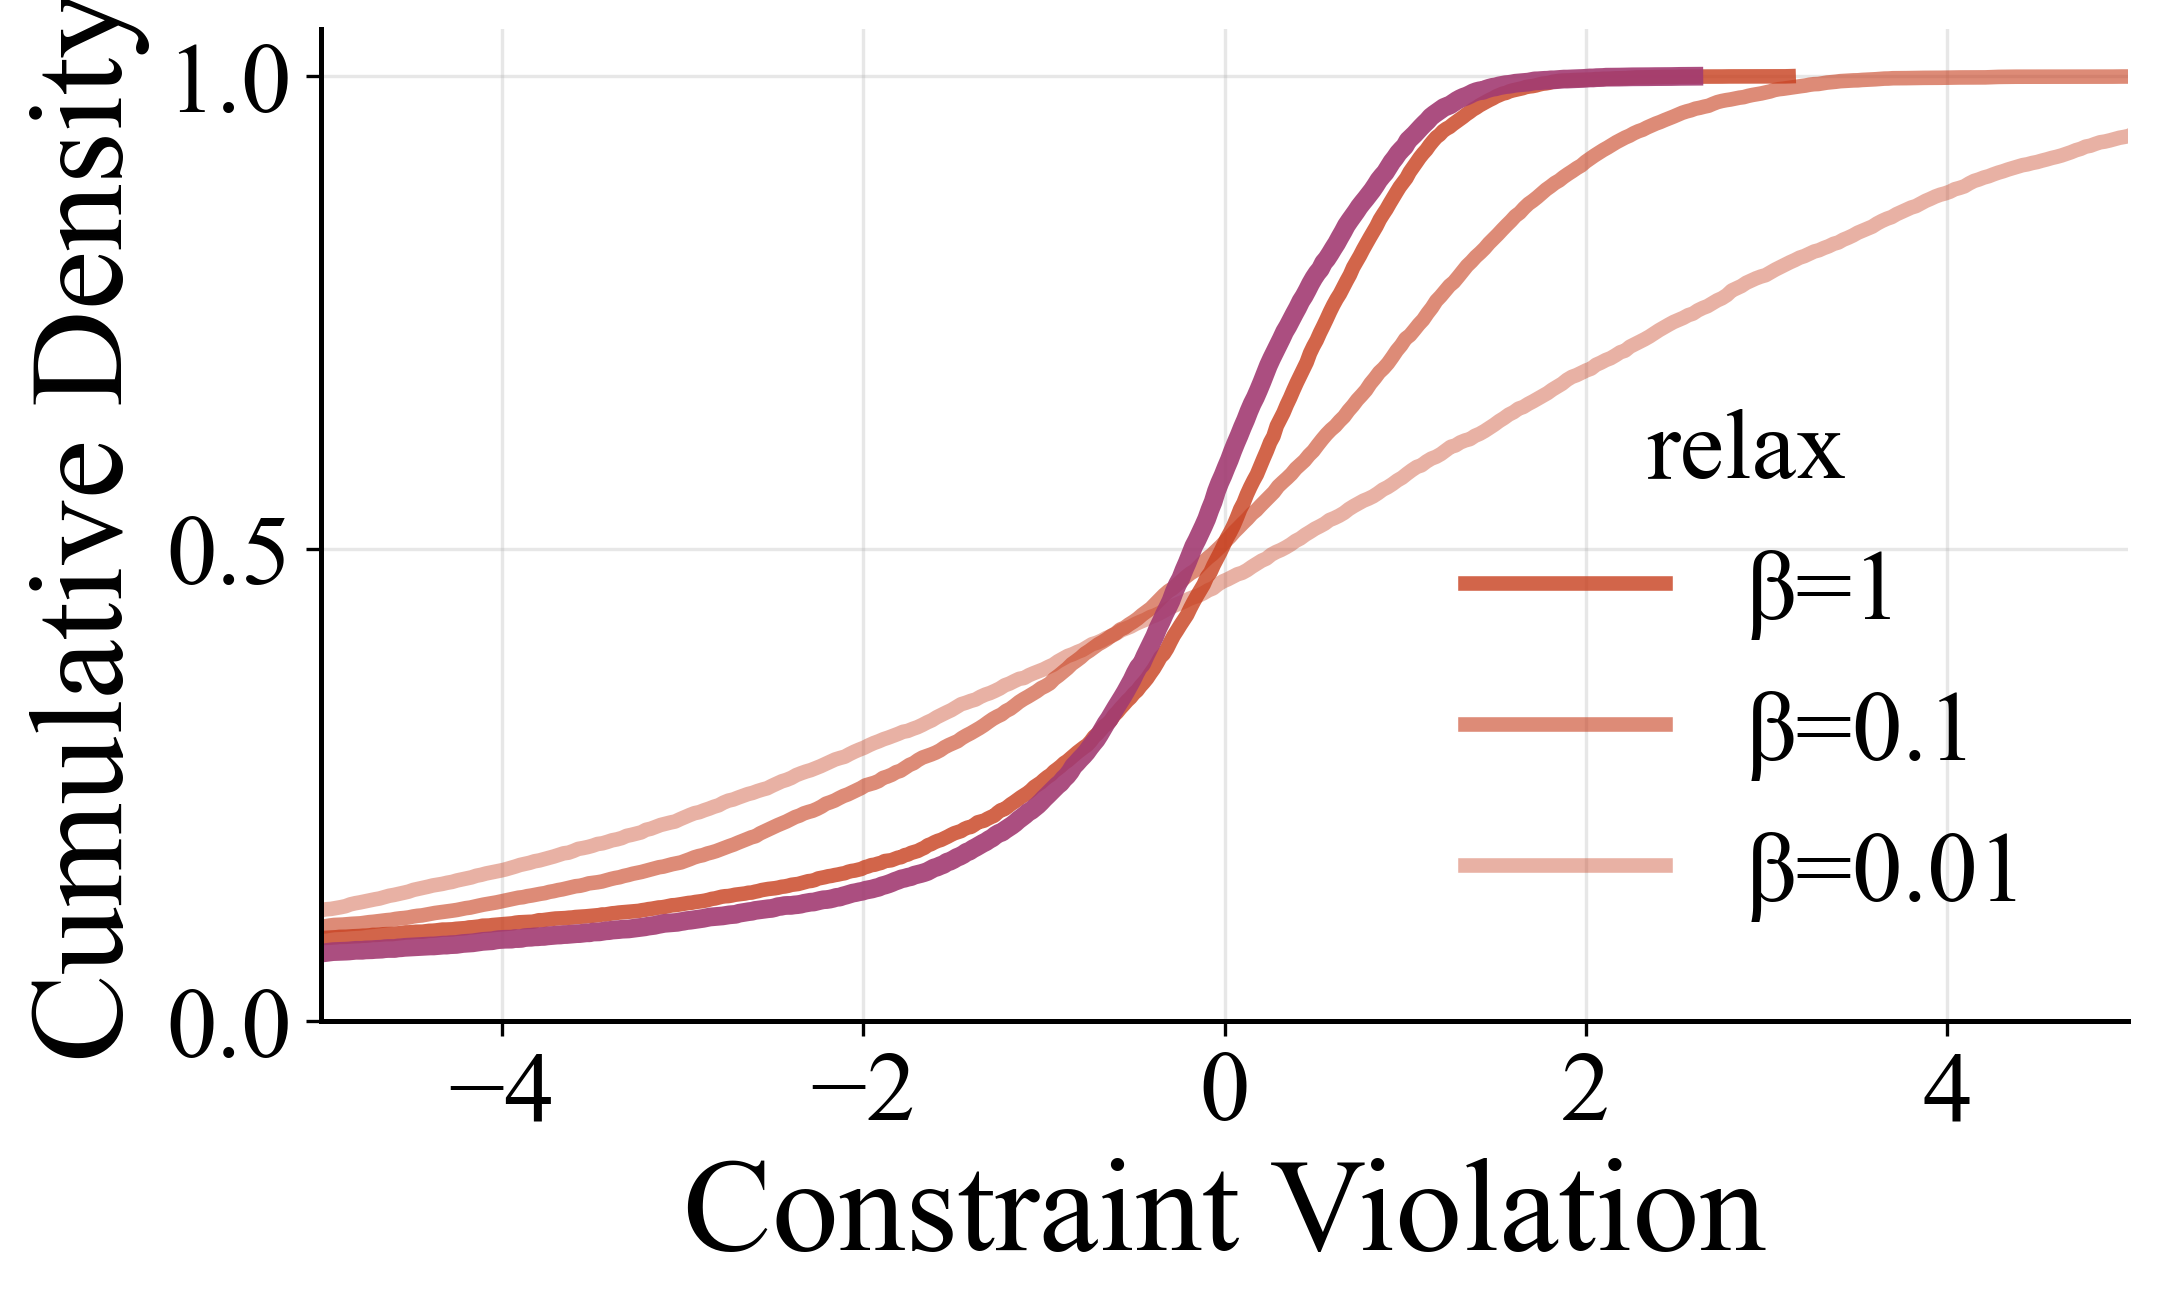

Saved figure to paper_figures/constraint_slack_cdf_(eval)_resilient_.pdf


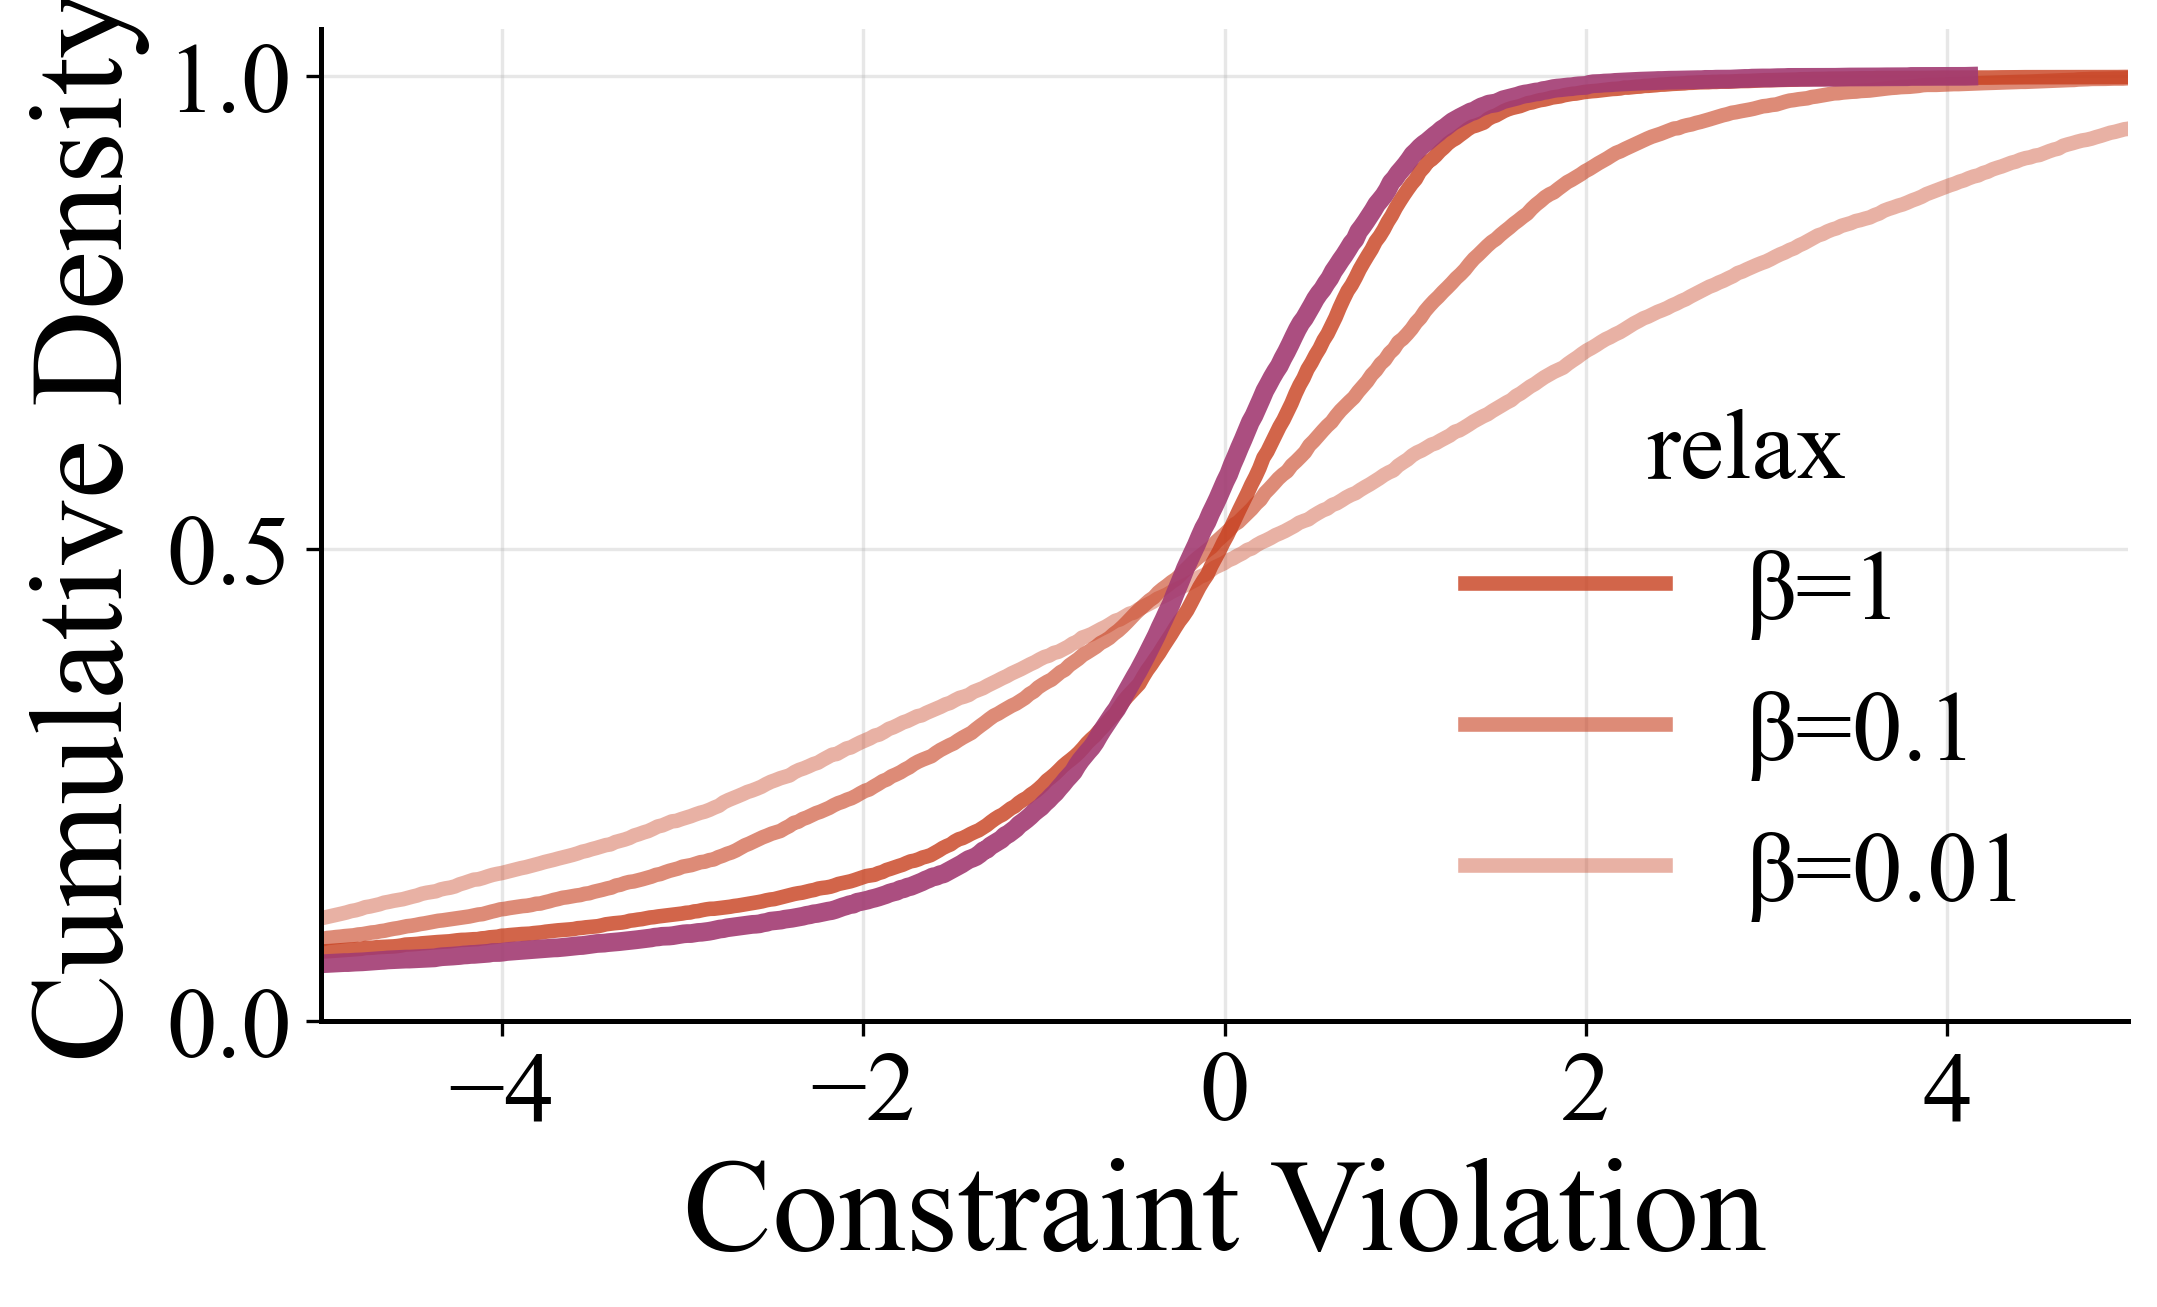

Train Slacks Statistics:
   Method      Mean      Std      P90      P99  CVaR_90  CVaR_99       Max
resilient -0.928216 2.826510 1.031250 1.718750 1.339647 1.982608  3.122070
 aug_dual -0.917474 2.653248 0.894531 1.519531 1.181117 1.799159  2.597656
resilient -0.977433 3.354411 1.929138 3.210967 2.516114 3.586526  5.207031
resilient -0.207335 3.864044 4.312500 6.664141 5.456225 7.320977 10.265625

Eval Slacks Statistics:
   Method      Mean      Std      P90      P99  CVaR_90  CVaR_99       Max
resilient -0.789000 2.675910 1.085938 2.351655 1.620996 3.217789  6.318359
 aug_dual -0.763170 2.476717 0.976562 1.962949 1.400539 2.527253  4.119141
resilient -0.849020 3.163081 2.000146 3.847656 2.830145 4.679349  6.867188
resilient -0.252418 3.718700 4.238281 6.729541 5.379253 7.577693 10.593750


In [5]:
# Filter runs and plot cumulative constraint slack histograms (train vs eval)


# PLOTTING RESILIENT
resilient_coef = [0.01,0.1,1]  # exp.loss_tol filter (set None to disable)
dropout = 0.05   # train.dropout filter (set None to disable)
model_name = "answerdotai/ModernBERT-base"
loss_type = ["resilient","aug_dual"]
dual_step_size = 0.1
loss_tol = [1]


def _run_passes_filters(run, loss_tol=None, dropout=None):
    cfg_exp = run.config.get('exp', {})
    cfg_train = run.config.get('train', {})
    if loss_tol is not None and cfg_exp.get('loss_tol') not in loss_tol:
        return False
    if dropout is not None and cfg_train.get('dropout') != dropout:
        return False
    if cfg_exp.get('model_name') != model_name:
        return False
    if cfg_exp.get('loss_type') not in loss_type:
        return False
    if cfg_exp.get('dual_step_size') != dual_step_size:
        return False
    if cfg_exp.get('resilient_coef') not in resilient_coef:
        return False
    return True

filtered_runs = [r for r in runs if r.state == 'finished' and _run_passes_filters(r, resilient_coef, dropout)]
print(f'Filtered runs: {len(filtered_runs)}')
# print loss_type and loss_alpha for each filtered run
for r in filtered_runs:
    loss_type = r.config.get('exp', {}).get('loss_type')
    loss_alpha = r.config.get('exp', {}).get('loss_alpha')
    print(f'  Run: {r.name}, loss_type: {loss_type}, loss_alpha: {loss_alpha}, resilient_coef: {r.config.get("exp", {}).get("resilient_coef")}')

# filtered_runs = [r for i, r in enumerate(filtered_runs) if i in indexes_to_filter]

pattern = re.compile(
    r'^(?:.*/)?constraint_slacks_epoch_([0-9.]+)_(train|eval)_(\d+)_([A-Za-z0-9]+)\.table\.json$'
)

def _latest_constraint_file(run, split):
    # Pick the file with the max epoch; tie-breaker max step
    candidates = []
    for f in list(run.files(per_page=1000)):
        m = pattern.match(f.name)
        if not m:
            continue
        epoch = float(m.group(1))
        file_split = m.group(2)
        step = int(m.group(3))
        if file_split != split:
            continue
        candidates.append((epoch, step, f))
    if not candidates:
        return None
    candidates.sort(key=lambda x: (x[0], x[1]))
    return candidates[-1][2]

def _load_constraint_slacks(file_obj, run_id, loss_tol):
    run_dir = Path('./wandb_downloads') / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    local_path = run_dir / file_obj.name
    file_obj.download(root=str(run_dir), replace=True)
    with open(local_path, 'r') as f:
        data = json.load(f)
    slacks = []
    for row in data.get('data', []):
        if row:
            slacks.append(float(row[0])-loss_tol + 1.0)
    return slacks

def _collect_slacks_by_split(runs, split):
    out = []
    aug_dual_kept = False
    for run in runs:
        f = _latest_constraint_file(run, split)
        if f is None:
            continue
        try:
            slacks = _load_constraint_slacks(f, run.id, loss_tol=run.config.get('exp', {}).get('loss_tol'))
        except Exception as e:
            print(f'Failed to load {split} slacks for {run.name}: {e}')
            continue

        # Keep only ONE aug_dual baseline run (ε=1, and default loss_alpha=1 if present)
        if run.config.get('exp', {}).get('loss_type') == 'aug_dual':
            try:
                if float(run.config.get('exp', {}).get('loss_tol')) != 1.0:
                    continue
                loss_alpha = run.config.get('exp', {}).get('loss_alpha')
                if loss_alpha is not None and float(loss_alpha) != 1.0:
                    continue
            except Exception:
                continue

            if aug_dual_kept:
                continue
            aug_dual_kept = True

        out.append({
            'run_id': run.id,
            'run_name': run.name,
            'loss_type': run.config.get('exp', {}).get('loss_type'),
            'slacks': np.array(slacks, dtype=float),
            'alpha': run.config.get('exp', {}).get('loss_alpha'),
            'loss_tol': run.config.get('exp', {}).get('loss_tol'),
            'resilient_coef': run.config.get('exp', {}).get('resilient_coef'),
        })
    return out

def _plot_cumulative(slack_sets, title):
    if not slack_sets:
        print(f'No data for {title}')
        return

    hp_key_by_loss_type = {
        'avg': 'loss_tol',  # ε
        'penalty': 'alpha',  # λ_o
        'resilient': 'resilient_coef',  # β
    }

    hp_ranges = {}
    for lt, hp_key in hp_key_by_loss_type.items():
        vals = [
            float(e.get(hp_key))
            for e in slack_sets
            if e.get('loss_type') == lt and e.get(hp_key) is not None
        ]
        uniq = sorted(set(vals))
        if len(uniq) > 1:
            hp_ranges[lt] = (hp_key, min(uniq), max(uniq))

    is_ablation = len(hp_ranges) > 0
    legend_title = method_abbrev(next(iter(hp_ranges))) if len(hp_ranges) == 1 else None

    plt.figure(figsize=(8, 5))
    bins = 1000  # large number of bins for crude but smooth cumulative curve
    for entry in sorted(slack_sets, key=lambda e: e.get('loss_type') == 'aug_dual'):
        slacks = entry['slacks']
        counts, edges = np.histogram(slacks, bins=bins)
        cdf = np.cumsum(counts) / counts.sum() if counts.sum() > 0 else np.zeros_like(counts)
        x = edges[1:]

        lt = entry['loss_type']
        label = format_method_label(entry)
        if is_ablation and lt == 'aug_dual':
            label = '_nolegend_'
        elif is_ablation and lt in hp_ranges:
            hp_key = hp_ranges[lt][0]
            if hp_key == 'alpha':
                label = f"$\\lambda_0$={_fmt_hp(entry['alpha'])}"
            elif hp_key == 'loss_tol':
                label = f"ε={_fmt_hp(entry['loss_tol'])}"
            elif hp_key == 'resilient_coef':
                label = f"β={_fmt_hp(entry['resilient_coef'])}"

        style = {'color': method_color(lt), 'alpha': 0.90, 'linewidth': 4.5}
        if lt in hp_ranges:
            hp_key, hp_min, hp_max = hp_ranges[lt]
            style = style_for_entry(entry, hp_key, hp_min=hp_min, hp_max=hp_max)

        plt.plot(x, cdf, label=label, **style)

    plt.xlabel('Constraint Violation')
    plt.ylabel('Cumulative Density')
    plt.xlim(-5, 5)
    plt.ylim(0, 1.05)
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        point_idx = next((i for i, l in enumerate(labels) if str(l).startswith('point')), None)
        if point_idx is not None:
            handles = [handles[point_idx]] + [h for i, h in enumerate(handles) if i != point_idx]
            labels = [labels[point_idx]] + [l for i, l in enumerate(labels) if i != point_idx]
        legend_kwargs = {'frameon': False, 'fontsize': 24, 'loc': 'lower right'}
        if legend_title is not None:
            legend_kwargs.update({'title': legend_title, 'title_fontsize': 24})
        ax.legend(handles, labels, **legend_kwargs)
    plt.tight_layout()

    # save as pdf
    filename = title.lower().replace(' ', '_') + '_resilient_' + '.pdf'
    filepath = output_dir / filename
    plt.savefig(filepath)
    print(f'Saved figure to {filepath}')

    plt.show()

train_slacks = _collect_slacks_by_split(filtered_runs, 'train')
eval_slacks = _collect_slacks_by_split(filtered_runs, 'eval')

_plot_cumulative(train_slacks, 'Constraint Slack CDF (Train)')
_plot_cumulative(eval_slacks, 'Constraint Slack CDF (Eval)')



# Create a table with distribution statistics (mean, std, percentiles, CVaR) for train and eval slacks
def _compute_slack_statistics(slack_sets):
    """Compute statistics for slack distributions"""
    stats = []
    for entry in slack_sets:
        slacks = entry['slacks']
        stats.append({
            'Method': entry['loss_type'] if entry['loss_type'] != 'penalty' else f"penalty ($\lambda_0=${entry['alpha']})",
            'Mean': np.mean(slacks),
            'Std': np.std(slacks),
            'P90': np.percentile(slacks, 90),
            'P99': np.percentile(slacks, 99),
            'CVaR_90': np.mean(slacks[slacks >= np.percentile(slacks, 90)]),
            'CVaR_99': np.mean(slacks[slacks >= np.percentile(slacks, 99)]),
            'Max': np.max(slacks),
        })
    return pd.DataFrame(stats)

train_stats = _compute_slack_statistics(train_slacks)
eval_stats = _compute_slack_statistics(eval_slacks)

print("Train Slacks Statistics:")
print(train_stats.to_string(index=False))
print("\nEval Slacks Statistics:")
print(eval_stats.to_string(index=False))

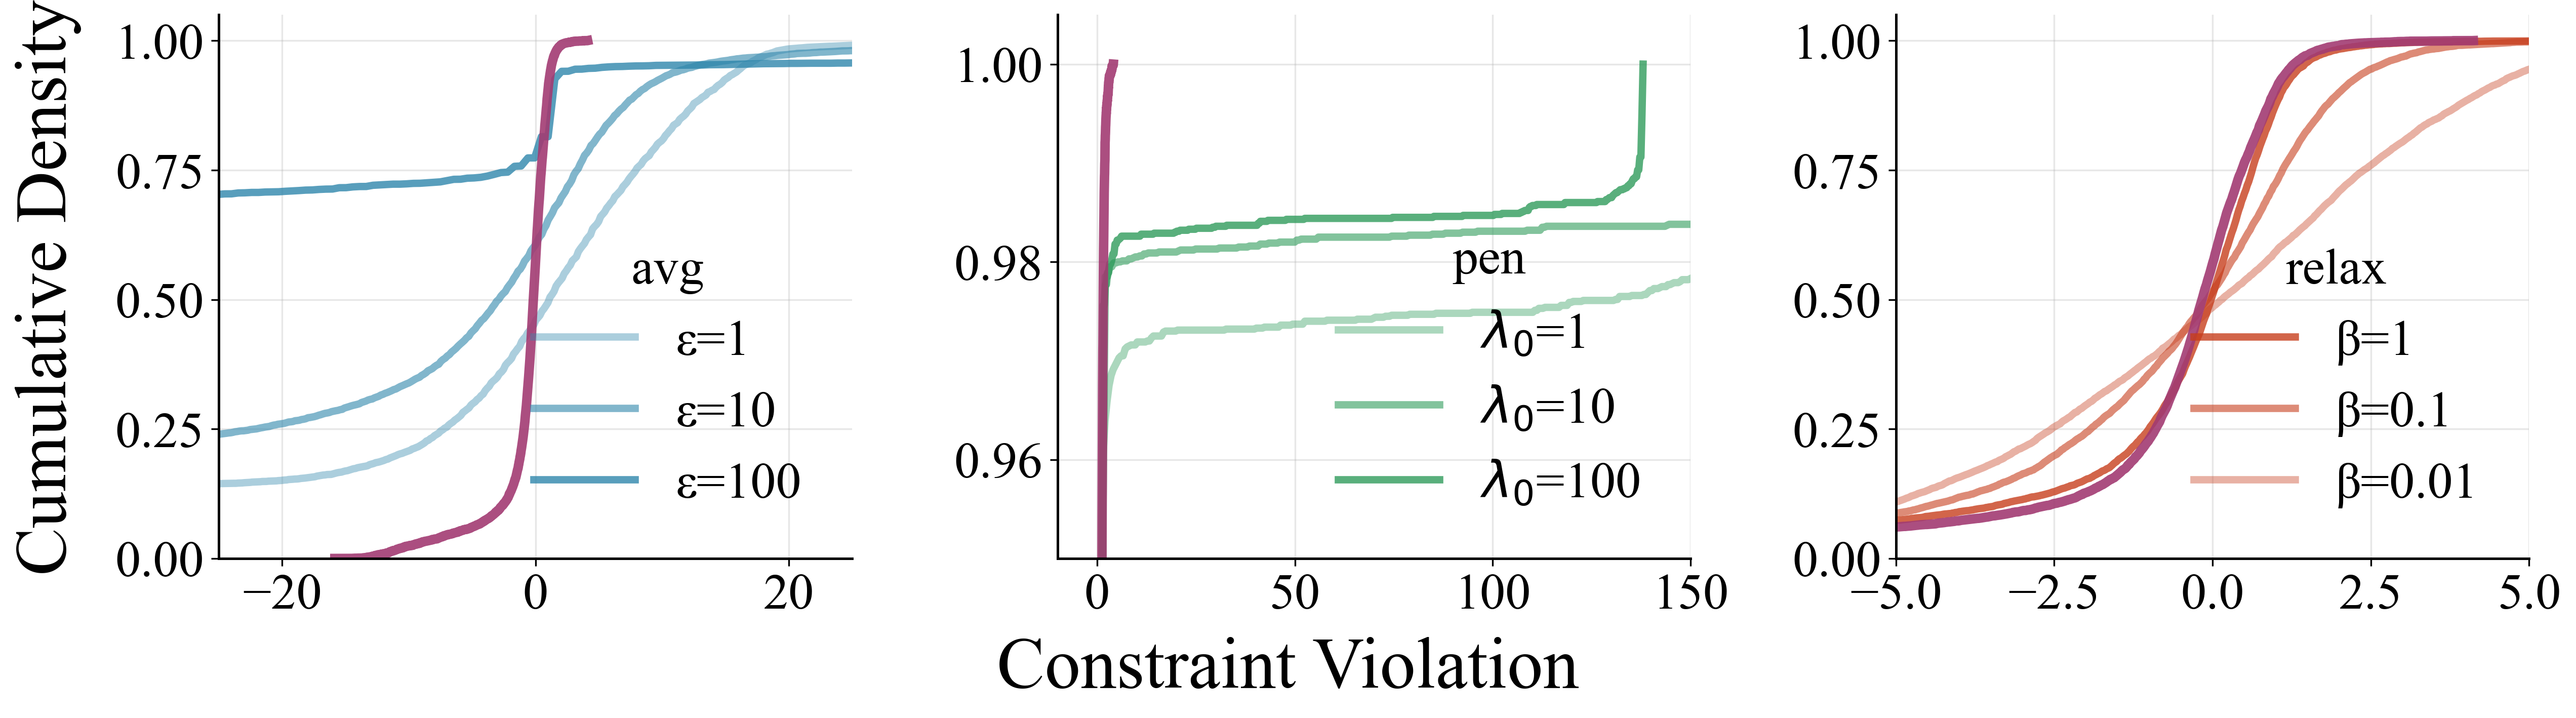

Saved figure to paper_figures/constraint_slack_cdf_(eval)_avg_penalty_resilient_combined.pdf


In [8]:
# One figure, three eval CDFs: same filtering + matplotlib plotting as the standalone
# penalty / avg / resilient cells above (not stitched PDFs).

pattern = re.compile(
    r'^(?:.*/)?constraint_slacks_epoch_([0-9.]+)_(train|eval)_(\d+)_([A-Za-z0-9]+)\.table\.json$'
)


def _triple_latest_relaxed(run, split):
    candidates = []
    for f in list(run.files(per_page=1000)):
        m = pattern.match(f.name)
        if not m:
            continue
        epoch = float(m.group(1))
        if m.group(2) != split:
            continue
        step = int(m.group(3))
        candidates.append((epoch, step, f))
    if not candidates:
        return None
    candidates.sort(key=lambda x: (x[0], x[1]))
    return candidates[-1][2]


def _triple_load_slacks_relaxed(file_obj, run_id, loss_tol):
    run_dir = Path('./wandb_downloads') / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    local_path = run_dir / file_obj.name
    file_obj.download(root=str(run_dir), replace=True)
    with open(local_path, 'r') as fh:
        data = json.load(fh)
    slacks = []
    for row in data.get('data', []):
        if row:
            slacks.append(float(row[0]) - loss_tol + 1.0)
    return slacks


def _collect_relaxed(runs, split):
    out = []
    aug_dual_kept = False
    for run in runs:
        f_obj = _triple_latest_relaxed(run, split)
        if f_obj is None:
            continue
        try:
            slacks = _triple_load_slacks_relaxed(
                f_obj, run.id, loss_tol=run.config.get('exp', {}).get('loss_tol'))
        except Exception as e:
            print(f'Failed to load {split} slacks for {run.name}: {e}')
            continue

        if run.config.get('exp', {}).get('loss_type') == 'aug_dual':
            try:
                if float(run.config.get('exp', {}).get('loss_tol')) != 1.0:
                    continue
                loss_alpha = run.config.get('exp', {}).get('loss_alpha')
                if loss_alpha is not None and float(loss_alpha) != 1.0:
                    continue
            except Exception:
                continue
            if aug_dual_kept:
                continue
            aug_dual_kept = True

        out.append({
            'run_id': run.id,
            'run_name': run.name,
            'loss_type': run.config.get('exp', {}).get('loss_type'),
            'slacks': np.array(slacks, dtype=float),
            'alpha': run.config.get('exp', {}).get('loss_alpha'),
            'loss_tol': run.config.get('exp', {}).get('loss_tol'),
            'resilient_coef': run.config.get('exp', {}).get('resilient_coef'),
        })
    return out


def _relax_cdf_ax(ax, slack_sets, xlim, ylim, *, show_ylabel: bool, base_linestyle=None, show_xlabel=True, axis_label_fontsize=None, sort_hp_key=None):
    if axis_label_fontsize is None:
        axis_label_fontsize = float(plt.rcParams.get('axes.labelsize', 26))
    if not slack_sets:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        return

    hp_key_by_loss_type = {
        'avg': 'loss_tol',
        'penalty': 'alpha',
        'resilient': 'resilient_coef',
    }

    hp_ranges = {}
    for lt, hp_key in hp_key_by_loss_type.items():
        vals = [
            float(e.get(hp_key))
            for e in slack_sets
            if e.get('loss_type') == lt and e.get(hp_key) is not None
        ]
        uniq = sorted(set(vals))
        if len(uniq) > 1:
            hp_ranges[lt] = (hp_key, min(uniq), max(uniq))

    is_ablation = len(hp_ranges) > 0
    legend_title = method_abbrev(next(iter(hp_ranges))) if len(hp_ranges) == 1 else None

    aug = [e for e in slack_sets if e.get('loss_type') == 'aug_dual']
    rest = [e for e in slack_sets if e.get('loss_type') != 'aug_dual']
    if sort_hp_key == 'alpha':
        rest = sorted(rest, key=lambda e: float(e.get('alpha') or 0.0))
    elif sort_hp_key == 'loss_tol':
        rest = sorted(rest, key=lambda e: float(e.get('loss_tol') or 0.0))
    elif sort_hp_key == 'resilient_coef':
        rest = sorted(rest, key=lambda e: float(e.get('resilient_coef') or 0.0))
    plot_order = rest + aug

    bins = 1000
    for entry in plot_order:
        slacks = entry['slacks']
        counts, edges = np.histogram(slacks, bins=bins)
        cdf = np.cumsum(counts) / counts.sum() if counts.sum() > 0 else np.zeros_like(counts)
        x = edges[1:]

        lt = entry['loss_type']
        label = format_method_label(entry)
        if is_ablation and lt == 'aug_dual':
            label = '_nolegend_'
        elif is_ablation and lt in hp_ranges:
            hp_key = hp_ranges[lt][0]
            if hp_key == 'alpha':
                label = f"$\\lambda_0$={_fmt_hp(entry['alpha'])}"
            elif hp_key == 'loss_tol':
                label = f"ε={_fmt_hp(entry['loss_tol'])}"
            elif hp_key == 'resilient_coef':
                label = f"β={_fmt_hp(entry['resilient_coef'])}"

        style = {'color': method_color(lt), 'alpha': 0.90, 'linewidth': 4.5}
        if lt in hp_ranges:
            hp_key, hp_min, hp_max = hp_ranges[lt]
            style = style_for_entry(entry, hp_key, hp_min=hp_min, hp_max=hp_max)
        if base_linestyle is not None:
            style['linestyle'] = base_linestyle

        ax.plot(x, cdf, label=label, **style)

    if show_xlabel:
        ax.set_xlabel('Constraint Violation', fontsize=axis_label_fontsize, labelpad=14)
    if show_ylabel:
        ax.set_ylabel('Cumulative Density', fontsize=axis_label_fontsize, labelpad=16)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        point_idx = next((i for i, l in enumerate(labels) if str(l).startswith('point')), None)
        if point_idx is not None:
            handles = [handles[point_idx]] + [h for i, h in enumerate(handles) if i != point_idx]
            labels = [labels[point_idx]] + [l for i, l in enumerate(labels) if i != point_idx]
        legend_kwargs = {'frameon': False, 'fontsize': 24, 'loc': 'lower right'}
        if legend_title is not None:
            legend_kwargs.update({'title': legend_title, 'title_fontsize': 24})
        ax.legend(handles, labels, **legend_kwargs)


# --- Penalty block (matches standalone penalty cell) ---
_loss_tol_pen = [1.0]
_dropout = 0.05
_model = 'answerdotai/ModernBERT-base'
_loss_types_pen = ['penalty', 'aug_dual']
_dual_pen = 0.1


def _ok_pen(run):
    cfg_exp = run.config.get('exp', {})
    cfg_train = run.config.get('train', {})
    if _loss_tol_pen is not None and cfg_exp.get('loss_tol') not in _loss_tol_pen:
        return False
    if cfg_train.get('dropout') != _dropout:
        return False
    if cfg_exp.get('model_name') != _model:
        return False
    if cfg_exp.get('loss_type') not in _loss_types_pen:
        return False
    if cfg_exp.get('dual_step_size') != _dual_pen and cfg_exp.get('loss_type') in ['aug_dual', 'avg']:
        return False
    if cfg_exp.get('loss_type') == 'penalty':
        la = cfg_exp.get('loss_alpha')
        try:
            fv = float(la)
        except (TypeError, ValueError):
            return False
        if not any(abs(fv - t) <= max(1e-6, 1e-4 * abs(t)) for t in (1.0, 10.0, 100.0)):
            return False
    return True


runs_penalty = [r for r in runs if r.state == 'finished' and _ok_pen(r)]

# --- Avg block (matches standalone avg cell) ---
_loss_tol_avg = [1.0, 10, 100]
_loss_types_avg = ['avg', 'aug_dual']
_dual_avg = 0.1


def _ok_avg(run):
    cfg_exp = run.config.get('exp', {})
    cfg_train = run.config.get('train', {})
    if _loss_tol_avg is not None and cfg_exp.get('loss_tol') not in _loss_tol_avg:
        return False
    if cfg_train.get('dropout') != _dropout:
        return False
    if cfg_exp.get('model_name') != _model:
        return False
    if cfg_exp.get('loss_type') not in _loss_types_avg:
        return False
    if cfg_exp.get('dual_step_size') != _dual_avg:
        return False
    return True


runs_avg = [r for r in runs if r.state == 'finished' and _ok_avg(r)]

# --- Resilient block (matches standalone resilient cell; loss_tol filter uses [1]) ---
_res_coefs = [0.01, 0.1, 1]
_loss_tol_res = [1]
_loss_types_res = ['resilient', 'aug_dual']
_dual_res = 0.1


def _ok_res(run):
    cfg_exp = run.config.get('exp', {})
    cfg_train = run.config.get('train', {})
    if _loss_tol_res is not None and cfg_exp.get('loss_tol') not in _loss_tol_res:
        return False
    if cfg_train.get('dropout') != _dropout:
        return False
    if cfg_exp.get('model_name') != _model:
        return False
    if cfg_exp.get('loss_type') not in _loss_types_res:
        return False
    if cfg_exp.get('dual_step_size') != _dual_res:
        return False
    if cfg_exp.get('resilient_coef') not in _res_coefs:
        return False
    return True


runs_resilient = [r for r in runs if r.state == 'finished' and _ok_res(r)]

eval_penalty = _collect_relaxed(runs_penalty, 'eval')
eval_avg = _collect_relaxed(runs_avg, 'eval')
eval_res = _collect_relaxed(runs_resilient, 'eval')

fig, axes = plt.subplots(1, 3, figsize=(17.6, 5))
_TRIPLE_LBL = 34
_relax_cdf_ax(axes[0], eval_avg, (-25, 25), (0, 1.05), show_ylabel=True, base_linestyle='-', show_xlabel=False, axis_label_fontsize=_TRIPLE_LBL)
_relax_cdf_ax(axes[1], eval_penalty, (-10, 150), (0.95, 1.005), show_ylabel=False, base_linestyle=None, show_xlabel=False, axis_label_fontsize=_TRIPLE_LBL, sort_hp_key='alpha')
_relax_cdf_ax(axes[2], eval_res, (-5, 5), (0, 1.05), show_ylabel=False, base_linestyle=None, show_xlabel=False, axis_label_fontsize=_TRIPLE_LBL)

fig.supxlabel('Constraint Violation', fontsize=_TRIPLE_LBL)
fig.tight_layout()
fig.subplots_adjust(bottom=0.2)
_out_cdf = output_dir / 'constraint_slack_cdf_(eval)_avg_penalty_resilient_combined.pdf'
fig.savefig(_out_cdf, bbox_inches='tight')
plt.show()
print(f'Saved figure to {_out_cdf}')

